In [155]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from Bio import SeqIO


pep_hits_long = pd.read_csv('long_neut_samples_092326.csv')

In [156]:
lassa = pep_hits_long[pep_hits_long['species'] == 'Mammarenavirus lassaense'].copy()

## importing the reference sequences fetched from UniProt (UP000002473_11622.fasta)

In [157]:
records = list(SeqIO.parse('UP000002473_11622_LASV_Josiah_reference.fasta', 'fasta'))

for r in records:
    print(r.id, len(r.seq))

sp|O09705|L_LASSJ 2218
sp|O73557|Z_LASSJ 99
sp|P08669|GLYC_LASSJ 491
sp|P13699|NCAP_LASSJ 569


In [158]:
reference_by_protein = {
    "polymerase": str(next(r.seq for r in records if "O09705" in r.id)),
    "glycoprotein": str(next(r.seq for r in records if "P08669" in r.id)),
    "nucleoprotein": str(next(r.seq for r in records if "P13699" in r.id)),
    "z protein": str(next(r.seq for r in records if "O73557" in r.id)),
}

In [159]:
print(lassa['category'].value_counts())
print(lassa['sequence'].nunique())
print(lassa['protein_std'].unique())

category
Household contact    29412
Lassa survivor       23478
Name: count, dtype: int64
258
['nucleoprotein' 'polymerase' 'glycoprotein' 'z protein']


## import PairwiseAligner and use BLOSUM62 matrix for local protein alignment

In [160]:
from Bio.Align import PairwiseAligner
from Bio.Align import substitution_matrices

aligner = PairwiseAligner()
aligner.mode = 'local' #want the peptide to find its best location within the reference

aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
aligner.open_gap_score = -10
aligner.extend_gap_score = -0.5

## choose glycoprotein

In [161]:
ref = reference_by_protein['glycoprotein']

np = lassa[lassa['protein_std'].eq("glycoprotein")].copy()

unique_np_peptides = np['sequence'].drop_duplicates()

In [162]:
ref

'MGQIVTFFQEVPHVIEEVMNIVLIALSVLAVLKGLYNFATCGLVGLVTFLLLCGRSCTTSLYKGVYELQTLELNMETLNMTMPLSCTKNNSHHYIMVGNETGLELTLTNTSIINHKFCNLSDAHKKNLYDHALMSIISTFHLSIPNFNQYEAMSCDFNGGKISVQYNLSHSYAGDAANHCGTVANGVLQTFMRMAWGGSYIALDSGRGNWDCIMTSYQYLIIQNTTWEDHCQFSRPSPIGYLGLLSQRTRDIYISRRLLGTFTWTLSDSEGKDTPGGYCLTRWMLIEAELKCFGNTAVAKCNEKHDEEFCDMLRLFDFNKQAIQRLKAEAQMSIQLINKAVNALINDQLIMKNHLRDIMGIPYCNYSKYWYLNHTTTGRTSLPKCWLVSNGSYLNETHFSDDIEQQADNMITEMLQKEYMERQGKTPLGLVDLFVFSTSFYLISIFLHLVKIPTHRHIVGKSCPKPHRLNHMGICSCGLYKQPGVPVKWKR'

## define mapping function

In [163]:
def map_peptide_to_reference(peptide, reference, aligner):
    """
    goal: map a peptide onto a reference protein. 

    output: returns a dictionary containing
    - alignment score
    - reference start/end (1-based)
    - reference positions covered by aligned peptide residues
    """

    #if no exact substring match, use local alignment
    alignment = aligner.align(reference, peptide)[0] #[0] to extract the first and best-scoring Alignment object from the results

    #aligner.align[0].aligned returns the start and end coordinates of the aligned segments for the target and query sequences
    ref_blocks, peptide_blocks = alignment.aligned

    ref_positions = []

    for (ref_start, ref_end), (pep_start, pep_end) in zip(ref_blocks, peptide_blocks):
        
        for i in range(ref_end - ref_start):
            ref_positions.append(ref_start + i + 1) #1-based

    #overall peptide coordinates
    pep_start = peptide_blocks[0][0] + 1
    pep_end = peptide_blocks[-1][1] #take the last block,so -1, in case there are more than one aligned blocks. and [1] for the end

    #total number of peptide residues included in the aligned blocks
    aligned_length = sum(end - start for start, end in peptide_blocks)

    #total number 

    return{
        'score': alignment.score, 
        'ref_start': ref_positions[0],
        'ref_end': ref_positions[-1],
        'ref_positions': ref_positions, 
        'pep_start' : pep_start, 
        'pep_end': pep_end,
        'aligned_length': aligned_length
    }


In [164]:
mapping = []

for peptide in unique_np_peptides:
    result = map_peptide_to_reference(peptide, ref, aligner)

    mapping.append({
        'sequence': peptide, 
        'score': result['score'], 
        'ref_start': result['ref_start'], 
        'ref_end': result['ref_end'], 
        'ref_positions': result['ref_positions'], 
        'pep_start': result['pep_start'], 
        'pep_end': result['pep_end'], 
        'aligned_pep_length': result['aligned_length']

    })

np_mapping = pd.DataFrame(mapping)

In [165]:
#check the length of peptide alignment, should be ~46

np_mapping['alignment_length'] = np_mapping['ref_positions'].str.len()

np_mapping['alignment_length'].describe()

count    17.0
mean     46.0
std       0.0
min      46.0
25%      46.0
50%      46.0
75%      46.0
max      46.0
Name: alignment_length, dtype: float64

In [166]:
np_mapping.sort_values('aligned_pep_length').head(2)

,sequence,score,ref_start,ref_end,ref_positions,pep_start,pep_end,aligned_pep_length,alignment_length
0,TSLPKCWLVSNGSYLNETHFSDDIEQQADNMITEMLQKEYMDRQGK,243.0,380,425,"[380, 381, 382, 383, 384, 385, 386, 387, 388, ...",1,46,46,46
1,SSNLYKGVYELQSLDLNMETLNMTMPLSCTKNNSHHYIRVGNETGL,219.0,58,103,"[58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 6...",1,46,46,46


In [167]:
#inspect the shortest mappings: 
np_mapping.sort_values("alignment_length").head(10)

,sequence,score,ref_start,ref_end,ref_positions,pep_start,pep_end,aligned_pep_length,alignment_length
0,TSLPKCWLVSNGSYLNETHFSDDIEQQADNMITEMLQKEYMDRQGK,243.0,380,425,"[380, 381, 382, 383, 384, 385, 386, 387, 388, ...",1,46,46,46
1,SSNLYKGVYELQSLDLNMETLNMTMPLSCTKNNSHHYIRVGNETGL,219.0,58,103,"[58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 6...",1,46,46,46
2,CNEKHDEEFCDMWRLFDFNKQAIQRLKAEAQMNIQLINKAVNALIN,227.0,301,346,"[301, 302, 303, 304, 305, 306, 307, 308, 309, ...",1,46,46,46
3,FHLSIPNFNQYEAMSCDFNGGKISIQYNLSHSYAGDAAQHCGTVAN,247.0,140,185,"[140, 141, 142, 143, 144, 145, 146, 147, 148, ...",1,46,46,46
4,NDQLIMKNHLRDIMGIPYCNYSKYWYLNNTVTGKSSLPKCWLVSNG,247.0,346,391,"[346, 347, 348, 349, 350, 351, 352, 353, 354, ...",1,46,46,46
5,YWYLNNTVTGKSSLPKCWLVSNGSYLNETHFSEDIEQQADNMITEM,235.0,369,414,"[369, 370, 371, 372, 373, 374, 375, 376, 377, ...",1,46,46,46
6,DQLIMKNHLRDIMGIPYCNYSKYWYLNHTVTGKTSLPKCWLVSNGS,256.0,347,392,"[347, 348, 349, 350, 351, 352, 353, 354, 355, ...",1,46,46,46
7,DQLIMKNHLRDIMGIPYCNYSKYWYLNHTITGKTSLPRCWLVSNGS,252.0,347,392,"[347, 348, 349, 350, 351, 352, 353, 354, 355, ...",1,46,46,46
8,WYLNHTITGKTSLPRCWLVSNGSYLNETQFSDDIEQQADNMITELL,232.0,370,415,"[370, 371, 372, 373, 374, 375, 376, 377, 378, ...",1,46,46,46
9,LELDMANLNMTMPLSCTKNNSHHYIMVGNETGLELTLTNTSIINHK,226.0,71,116,"[71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 8...",1,46,46,46


## merging the mapping back to the individual-level dataframe


In [168]:
np = np.merge(np_mapping, on='sequence', how='left')

In [169]:
np.shape

(3485, 26)

## .explode() turns one peptide/individual row to one row per amino-acid position covered by that peptide

In [170]:
np_residues = np.explode('ref_positions').rename(columns={'ref_positions': 'position'})

## keep only reactive peptides

In [171]:
reactive_residues = np_residues[np_residues['reactive']].copy()

## now we have the people and amino acid positions at which they have nucleoprotein antibody reactivity. But we need to remove contributions to the same amino-acid position. each individual can contribute at most one to a given amino acid position. 

In [172]:
reactive_residues = reactive_residues[['individual', 'cohort', 'category', 'position']].drop_duplicates()

In [173]:
reactive_residues['individual'].unique() #no US healthies, as expected

array(['C-109-3_4_E7', 'C-111-3_3_I6', 'C-112-1_3_B3', 'C-464-3_3_F9',
       'C-470-3_2_F8', 'C-475-2_2_F5', 'C-489-2_3_D5', 'C-508-2_4_A8',
       'S-107_SA1_A9', 'S-113_SA1_B4', 'S-115_SA1_A5', 'S-125_SA1_C3',
       'S-126_SA1_C4', 'S-148_SA1_E7', 'S-186_SA1_G3', 'S-488_SA1_H2',
       'C-114-3_3_B6', 'C-115-3_1_D6', 'C-191-3_1_A3', 'C-462-3_2_I6',
       'C-467-1_2_D6', 'C-475-1_3_G6', 'C-507-3_4_B8', 'C-510-1_3_H8',
       'C-512-1_5_C9', 'S-117_SA1_A6', 'S-136_SA1_D5', 'S-146_SA1_E4',
       'S-147_SA1_E6', 'S-442_SA2_F3', 'S-486_SA1_H1', 'C-113-3_1_G6',
       'C-446-1_2_C5', 'C-446-2_2_E7', 'C-446-3_2_G2', 'C-451-2_2_F6',
       'C-461-2_2_D2', 'C-469-3_7_H6', 'S-109_SA1_B1', 'S-110_SA1_B2',
       'S-466_SA1_I2', 'S-514_SA3_C8', 'C-122-3_3_B9', 'C-143-3_1_I2',
       'C-149-1_2_B1', 'C-190-3_3_D7', 'C-437-2_2_D8', 'C-441-2_3_E6',
       'C-443-2_2_G9', 'C-445-1_2_D1', 'C-450-1_1_F9', 'C-485-2_2_H6',
       'C-487-2_2_F3', 'C-510-2_4_A5', 'C-514-1_3_H2', 'S-105_SA1_A4',
      

## calculate number of individuals in each category

In [174]:
group_sizes = (
    np[['individual', 'cohort', 'category']].drop_duplicates().groupby(['cohort', 'category']).size().rename('n_individuals').reset_index()
)

group_sizes

,cohort,category,n_individuals
0,SL,Household contact,114
1,SL,Lassa survivor,91


## now count reactive individuals at each position

In [175]:
position_counts = (
    reactive_residues.groupby(['cohort', 'category', 'position'])['individual'] #reactive residues only include SL individuals
    .nunique()
    .rename('n_seroreactive')
    .reset_index()
)

position_counts.head(2)

,cohort,category,position,n_seroreactive
0,SL,Household contact,58,9
1,SL,Household contact,59,9


In [176]:
position_summary = position_counts.merge(group_sizes, on=['cohort', 'category'], how='left')

position_summary.head(2)

,cohort,category,position,n_seroreactive,n_individuals
0,SL,Household contact,58,9,114
1,SL,Household contact,59,9,114


In [177]:
position_summary['pct_seroreactive'] = (
    position_summary['n_seroreactive'] / position_summary['n_individuals'] * 100
)

In [178]:
position_summary.head(3)

,cohort,category,position,n_seroreactive,n_individuals,pct_seroreactive
0,SL,Household contact,58,9,114,7.894737
1,SL,Household contact,59,9,114,7.894737
2,SL,Household contact,60,9,114,7.894737


## add positions with zero seroreactivity 

In [179]:
all_positions = pd.DataFrame({'position': range(1, len(ref) + 1)}) #initiate a dataframe with one column

groups = np[['cohort', 'category']].drop_duplicates()

complete_grid = groups.merge(all_positions, how='cross')

complete_grid.head(2)

,cohort,category,position
0,SL,Household contact,1
1,SL,Household contact,2


In [180]:
position_summary = complete_grid.merge(
    position_summary,
    on=["cohort", "category", "position"],
    how="left"
)

position_summary["n_seroreactive"] = (
    position_summary["n_seroreactive"]
    .fillna(0)
)

position_summary = position_summary.drop(columns='n_individuals').merge(group_sizes, on=['cohort', 'category'], how='left')

position_summary['pct_seroreactive'] = 100 * position_summary['n_seroreactive'] / position_summary['n_individuals']

In [181]:
position_summary['category'].unique()

array(['Household contact', 'Lassa survivor'], dtype=object)

## Now going to plot the % of cohort/ category reactive to the amino acid positions of the glycoprotein

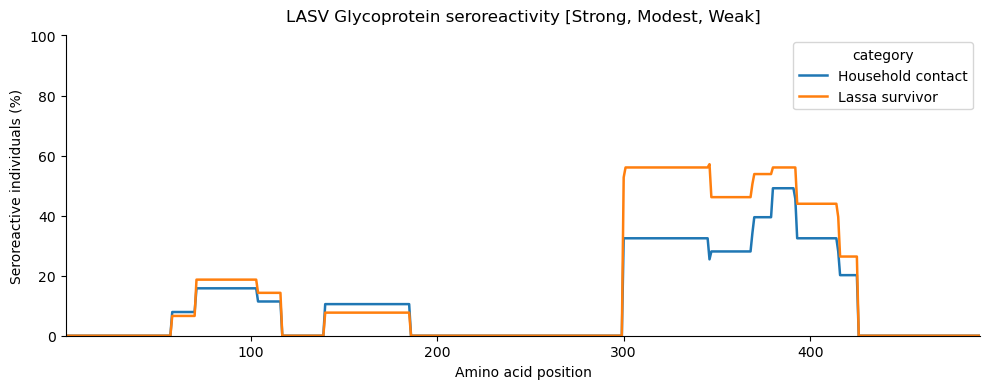

In [182]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 4))

sns.lineplot(
    data= position_summary, 
    x='position', 
    y='pct_seroreactive', 
    hue='category', 
    linewidth=1.8, 
    ax=ax
)

ax.set_xlabel('Amino acid position')
ax.set_ylabel('Seroreactive individuals (%)')
ax.set_xlim(1, len(ref)) #minimum and maximum position
ax.set_ylim(0,  100)

ax.spines['top'].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title('LASV Glycoprotein seroreactivity [Strong, Modest, Weak]', y=1.02)
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig('glycoprotein_reactivity_neut_samples.svg', format='svg')
plt.show()

In [183]:
lassa

,peptide,individual,z_score,rpk,sequence,species,genus,family,protein_std,accession,cohort,category,reactive,NP_FINAL_RESULT,GP_FINAL_RESULT,Neut_Percent,Neut_Result,Serology_Result_Corrected
4,AAA46284.1|?|Mammarenavirus_lassaense|?|?|?|?|...,C-109-3_4_E7,4.832718,5.063550,TERPLSSGVYMGNLSSQQLDQRRALLNMIGMTGVSGGGKGASNGIV,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,nucleoprotein,AAA46284.1,SL,Household contact,True,Positive,Positive,83.771946,Strong,Positive
25,AAO59509.1|polymerase|Mammarenavirus_lassaense...,C-109-3_4_E7,1.470043,1.164227,DNRSDHYEEIIALCHQGINNKLTAHEVKLQIEEEYQVFRNRLRGGE,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,AAO59509.1,SL,Household contact,False,Positive,Positive,83.771946,Strong,Positive
26,AAO59509.1|polymerase|Mammarenavirus_lassaense...,C-109-3_4_E7,-0.721962,0.180069,DGVVVEENLEQLTHQFKRASPILRFLYSDIEGEEDRRNTQAIKEHQ,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,AAO59509.1,SL,Household contact,False,Positive,Positive,83.771946,Strong,Positive
27,AAO59509.1|polymerase|Mammarenavirus_lassaense...,C-109-3_4_E7,-0.722601,0.000000,NKRLASFSPVLQDQDLELFVREVGDTSPDLLIGALSAMMLDRLKLR,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,AAO59509.1,SL,Household contact,False,Positive,Positive,83.771946,Strong,Positive
333,AHC95546.1|polymerase|Mammarenavirus_lassaense...,C-109-3_4_E7,0.875610,1.319421,LLDNRSGHYEEIIALCHQGINNKLTAHEVKLQIEEEYQVFRNRLRG,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,AHC95546.1,SL,Household contact,False,Positive,Positive,83.771946,Strong,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990782,XBA96071.1|protein|Mammarenavirus_lassaense|LF...,S-512_SA3_G9,-0.740793,0.000000,MGNKQAKASEKEKNSPRASLIPDATHLGPQFCKSCWFENKGLVECN,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,z protein,XBA96071.1,SL,Lassa survivor,False,Positive,Positive,83.696755,Strong,Positive
991390,XQN12076.1|polymerase|Mammarenavirus_lassaense...,S-512_SA3_G9,0.399414,1.695669,DNRSNHYEEVIASCHQGINNKLTAHEVKLQIEEEYQVFRNRLRKGE,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,XQN12076.1,SL,Lassa survivor,False,Positive,Positive,83.696755,Strong,Positive
991391,XQN12076.1|polymerase|Mammarenavirus_lassaense...,S-512_SA3_G9,-0.940182,0.188408,IEGQFLKVDKSQLLNELNNLYADKVVAEDNIEHLIYQFKRASPILR,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,XQN12076.1,SL,Lassa survivor,False,Positive,Positive,83.696755,Strong,Positive
991392,XQN12076.1|polymerase|Mammarenavirus_lassaense...,S-512_SA3_G9,-0.844840,0.000000,WLGSCFLSVNDRLVSLESTKRDLEKWVERRQQAERSRITQSSQCLS,Mammarenavirus lassaense,Mammarenavirus,Arenaviridae,polymerase,XQN12076.1,SL,Lassa survivor,False,Positive,Positive,83.696755,Strong,Positive
